In [26]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, roc_curve, 
                            multilabel_confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [27]:
df_original = pd.read_csv('ml-dataset-50-50-idle-timeout-2-17-10-2025-multiple-attacks.csv')
df_corrected = pd.read_csv('ml-dataset-50-50-idle-timeout-2-17-10-2025-multiple-attacks-corrected.csv')

print(f"\nOriginal Dataset shape: {df_original.shape}")
print(f"Corrected Dataset shape: {df_corrected.shape}")


Original Dataset shape: (3354, 72)
Corrected Dataset shape: (3354, 72)


In [28]:
print("DATASET STATISTICS COMPARISON")

print("\nORIGINAL DATASET:")
print(f"  Total samples: {len(df_original)}")
print(f"  Normal samples: {(df_original['attack'] == 0).sum()} ({(df_original['attack'] == 0).sum() / len(df_original) * 100:.2f}%)")
print(f"  Attack samples: {df_original['attack'].sum()} ({df_original['attack'].sum() / len(df_original) * 100:.2f}%)")
print(f"    - SYN attacks: {df_original['attack_syn'].sum()}")
print(f"    - UDP attacks: {df_original['attack_udp'].sum()}")
print(f"    - ICMP attacks: {df_original['attack_icmp'].sum()}")

print("\nCORRECTED DATASET:")
print(f"  Total samples: {len(df_corrected)}")
print(f"  Normal samples: {(df_corrected['attack'] == 0).sum()} ({(df_corrected['attack'] == 0).sum() / len(df_corrected) * 100:.2f}%)")
print(f"  Attack samples: {df_corrected['attack'].sum()} ({df_corrected['attack'].sum() / len(df_corrected) * 100:.2f}%)")
print(f"    - SYN attacks: {df_corrected['attack_syn'].sum()}")
print(f"    - UDP attacks: {df_corrected['attack_udp'].sum()}")
print(f"    - ICMP attacks: {df_corrected['attack_icmp'].sum()}")

print("\nIMPROVEMENT:")
print(f"  Additional attack samples: {df_corrected['attack'].sum() - df_original['attack'].sum()}")
print(f"    - Additional SYN: {df_corrected['attack_syn'].sum() - df_original['attack_syn'].sum()}")
print(f"    - Additional UDP: {df_corrected['attack_udp'].sum() - df_original['attack_udp'].sum()}")
print(f"    - Additional ICMP: {df_corrected['attack_icmp'].sum() - df_original['attack_icmp'].sum()}")

DATASET STATISTICS COMPARISON

ORIGINAL DATASET:
  Total samples: 3354
  Normal samples: 1777 (52.98%)
  Attack samples: 1577 (47.02%)
    - SYN attacks: 634
    - UDP attacks: 599
    - ICMP attacks: 344

CORRECTED DATASET:
  Total samples: 3354
  Normal samples: 1583 (47.20%)
  Attack samples: 1771 (52.80%)
    - SYN attacks: 734
    - UDP attacks: 651
    - ICMP attacks: 386

IMPROVEMENT:
  Additional attack samples: 194
    - Additional SYN: 100
    - Additional UDP: 52
    - Additional ICMP: 42


In [29]:
def prepare_data(df, task='binary'):
    """
    Prepare data for training.
    
    Args:
        df: DataFrame with features and labels
        task: 'binary' for attack vs normal, 'multiclass' for attack type classification
    
    Returns:
        X, y split into train and test sets
    """
    # Features (excluding timestamp and all attack labels)
    feature_cols = [col for col in df.columns if col not in ['timestamp', 'attack', 'attack_syn', 'attack_udp', 'attack_icmp']]
    X = df[feature_cols]
    
    if task == 'binary':
        # Binary classification: attack vs normal
        y = df['attack']
    elif task == 'multiclass':
        # Multi-class classification: normal (0), syn (1), udp (2), icmp (3)
        y = np.zeros(len(df), dtype=int)
        y[df['attack_syn'] == 1] = 1
        y[df['attack_udp'] == 1] = 2
        y[df['attack_icmp'] == 1] = 3
    
    return X, y

In [30]:
def train_and_evaluate_binary(X_train, X_test, y_train, y_test, dataset_name):
    """
    Train and evaluate binary classifier (attack vs normal).
    """
    print(f"\n{'='*80}")
    print(f"BINARY CLASSIFICATION - {dataset_name}")
    print(f"{'='*80}")
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    print("\nTraining Random Forest model...")
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
        verbose=0
    )
    
    rf_model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = rf_model.predict(X_test_scaled)
    y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    print(f"\n{'RESULTS':^40}")
    print("-" * 40)
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1-Score:  {metrics['f1']:.4f}")
    print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{'CONFUSION MATRIX':^40}")
    print("-" * 40)
    print(f"True Negatives:  {cm[0,0]:>6}")
    print(f"False Positives: {cm[0,1]:>6}")
    print(f"False Negatives: {cm[1,0]:>6}")
    print(f"True Positives:  {cm[1,1]:>6}")
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return {
        'model': rf_model,
        'scaler': scaler,
        'metrics': metrics,
        'confusion_matrix': cm,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'feature_importance': feature_importance
    }

In [31]:
#%%
def train_and_evaluate_multiclass(X_train, X_test, y_train, y_test, dataset_name):
    """
    Train and evaluate multi-class classifier (normal, syn, udp, icmp).
    """
    print(f"\n{'='*80}")
    print(f"MULTI-CLASS CLASSIFICATION - {dataset_name}")
    print(f"{'='*80}")
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    print("\nTraining Random Forest model...")
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
        verbose=0
    )
    
    rf_model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = rf_model.predict(X_test_scaled)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    # Per-class metrics
    class_names = ['Normal', 'SYN', 'UDP', 'ICMP']
    
    print(f"\n{'RESULTS':^60}")
    print("-" * 60)
    print(f"Overall Accuracy: {accuracy:.4f}")
    
    print(f"\n{'Classification Report':^60}")
    print("-" * 60)
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return {
        'model': rf_model,
        'scaler': scaler,
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'y_test': y_test,
        'y_pred': y_pred,
        'feature_importance': feature_importance,
        'class_names': class_names
    }

In [32]:
# Prepare data for both datasets
# Binary classification data
X_orig_bin, y_orig_bin = prepare_data(df_original, task='binary')
X_corr_bin, y_corr_bin = prepare_data(df_corrected, task='binary')

# Multi-class classification data
X_orig_multi, y_orig_multi = prepare_data(df_original, task='multiclass')
X_corr_multi, y_corr_multi = prepare_data(df_corrected, task='multiclass')

# Split data
X_train_orig_bin, X_test_orig_bin, y_train_orig_bin, y_test_orig_bin = train_test_split(
    X_orig_bin, y_orig_bin, test_size=0.2, random_state=42, stratify=y_orig_bin
)

X_train_corr_bin, X_test_corr_bin, y_train_corr_bin, y_test_corr_bin = train_test_split(
    X_corr_bin, y_corr_bin, test_size=0.2, random_state=42, stratify=y_corr_bin
)

X_train_orig_multi, X_test_orig_multi, y_train_orig_multi, y_test_orig_multi = train_test_split(
    X_orig_multi, y_orig_multi, test_size=0.2, random_state=42, stratify=y_orig_multi
)

X_train_corr_multi, X_test_corr_multi, y_train_corr_multi, y_test_corr_multi = train_test_split(
    X_corr_multi, y_corr_multi, test_size=0.2, random_state=42, stratify=y_corr_multi
)

print("Data preparation complete!")
print(f"Number of features: {X_orig_bin.shape[1]}")

Data preparation complete!
Number of features: 67


In [33]:
# Train and evaluate binary classification
print("BINARY CLASSIFICATION (ATTACK vs NORMAL)")

results_orig_bin = train_and_evaluate_binary(
    X_train_orig_bin, X_test_orig_bin, y_train_orig_bin, y_test_orig_bin,
    "ORIGINAL DATASET"
)

results_corr_bin = train_and_evaluate_binary(
    X_train_corr_bin, X_test_corr_bin, y_train_corr_bin, y_test_corr_bin,
    "CORRECTED DATASET"
)

BINARY CLASSIFICATION (ATTACK vs NORMAL)

BINARY CLASSIFICATION - ORIGINAL DATASET

Training Random Forest model...

                RESULTS                 
----------------------------------------
Accuracy:  0.9195
Precision: 0.8635
Recall:    0.9841
F1-Score:  0.9199
ROC-AUC:   0.9685

            CONFUSION MATRIX            
----------------------------------------
True Negatives:     307
False Positives:     49
False Negatives:      5
True Positives:     310

BINARY CLASSIFICATION - CORRECTED DATASET

Training Random Forest model...

                RESULTS                 
----------------------------------------
Accuracy:  0.9598
Precision: 0.9383
Recall:    0.9887
F1-Score:  0.9629
ROC-AUC:   0.9936

            CONFUSION MATRIX            
----------------------------------------
True Negatives:     294
False Positives:     23
False Negatives:      4
True Positives:     350


In [34]:
# Train and evaluate multi-class classification
print("MULTI-CLASS CLASSIFICATION (NORMAL, SYN, UDP, ICMP)")

results_orig_multi = train_and_evaluate_multiclass(
    X_train_orig_multi, X_test_orig_multi, y_train_orig_multi, y_test_orig_multi,
    "ORIGINAL DATASET"
)

results_corr_multi = train_and_evaluate_multiclass(
    X_train_corr_multi, X_test_corr_multi, y_train_corr_multi, y_test_corr_multi,
    "CORRECTED DATASET"
)

MULTI-CLASS CLASSIFICATION (NORMAL, SYN, UDP, ICMP)

MULTI-CLASS CLASSIFICATION - ORIGINAL DATASET

Training Random Forest model...

                          RESULTS                           
------------------------------------------------------------
Overall Accuracy: 0.9001

                   Classification Report                    
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.96      0.88      0.92       355
         SYN       0.78      0.90      0.83       127
         UDP       0.89      0.99      0.94       120
        ICMP       0.88      0.87      0.88        69

    accuracy                           0.90       671
   macro avg       0.88      0.91      0.89       671
weighted avg       0.91      0.90      0.90       671


MULTI-CLASS CLASSIFICATION - CORRECTED DATASET

Training Random Forest model...

                          RESULTS                           
-------------------

In [35]:
print("COMPARISON SUMMARY")

print("BINARY CLASSIFICATION IMPROVEMENT")

metrics_comparison_bin = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Original': [
        results_orig_bin['metrics']['accuracy'],
        results_orig_bin['metrics']['precision'],
        results_orig_bin['metrics']['recall'],
        results_orig_bin['metrics']['f1'],
        results_orig_bin['metrics']['roc_auc']
    ],
    'Corrected': [
        results_corr_bin['metrics']['accuracy'],
        results_corr_bin['metrics']['precision'],
        results_corr_bin['metrics']['recall'],
        results_corr_bin['metrics']['f1'],
        results_corr_bin['metrics']['roc_auc']
    ]
})

metrics_comparison_bin['Improvement'] = metrics_comparison_bin['Corrected'] - metrics_comparison_bin['Original']
metrics_comparison_bin['Improvement %'] = (metrics_comparison_bin['Improvement'] / metrics_comparison_bin['Original']) * 100

print(metrics_comparison_bin.to_string(index=False))

print("MULTI-CLASS CLASSIFICATION IMPROVEMENT")

accuracy_improvement = results_corr_multi['accuracy'] - results_orig_multi['accuracy']
accuracy_improvement_pct = (accuracy_improvement / results_orig_multi['accuracy']) * 100

print(f"Original Accuracy:  {results_orig_multi['accuracy']:.4f}")
print(f"Corrected Accuracy: {results_corr_multi['accuracy']:.4f}")
print(f"Improvement:        {accuracy_improvement:+.4f} ({accuracy_improvement_pct:+.2f}%)")

COMPARISON SUMMARY
BINARY CLASSIFICATION IMPROVEMENT
   Metric  Original  Corrected  Improvement  Improvement %
 Accuracy  0.919523   0.959762     0.040238       4.376013
Precision  0.863510   0.938338     0.074828       8.665571
   Recall  0.984127   0.988701     0.004574       0.464735
 F1-Score  0.919881   0.962861     0.042980       4.672317
  ROC-AUC  0.968544   0.993557     0.025013       2.582578
MULTI-CLASS CLASSIFICATION IMPROVEMENT
Original Accuracy:  0.9001
Corrected Accuracy: 0.9493
Improvement:        +0.0492 (+5.46%)


In [36]:
# Visualizations
color_original = '#3498db'  # Blue
color_corrected = '#2ecc71'  # Green
color_improvement_pos = '#27ae60'  # Dark green
color_improvement_neg = '#e74c3c'  # Red

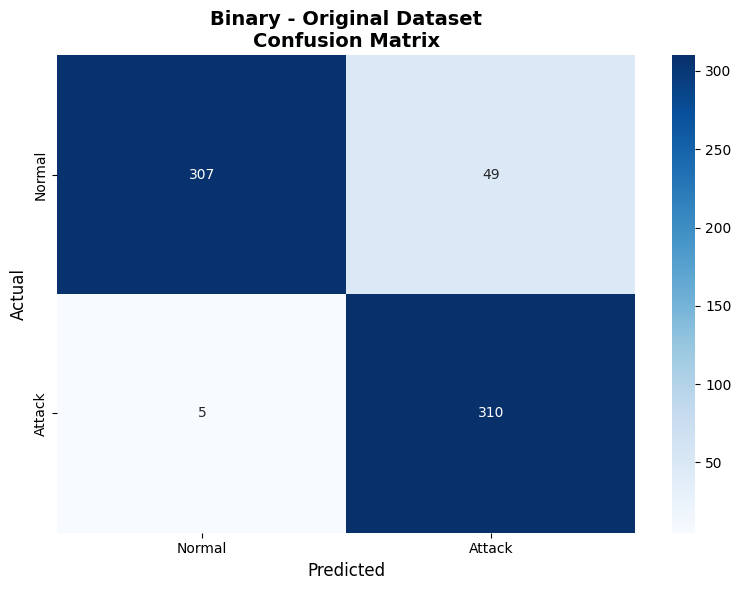

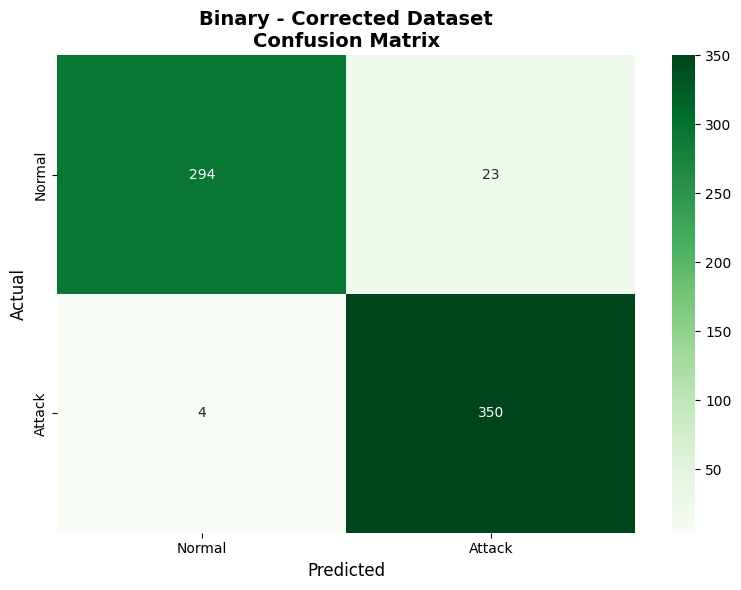

In [37]:
# 1. Binary Classification - Confusion Matrices Comparison
plt.figure(figsize=(8, 6))
sns.heatmap(results_orig_bin['confusion_matrix'], 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            cbar=True,
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])
plt.title('Binary - Original Dataset\nConfusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# 1.1 Binary Classification - Corrected Dataset
plt.figure(figsize=(8, 6))
sns.heatmap(results_corr_bin['confusion_matrix'], 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            cbar=True,
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])
plt.title('Binary - Corrected Dataset\nConfusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('random_forest_results/binary_original_dataset_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

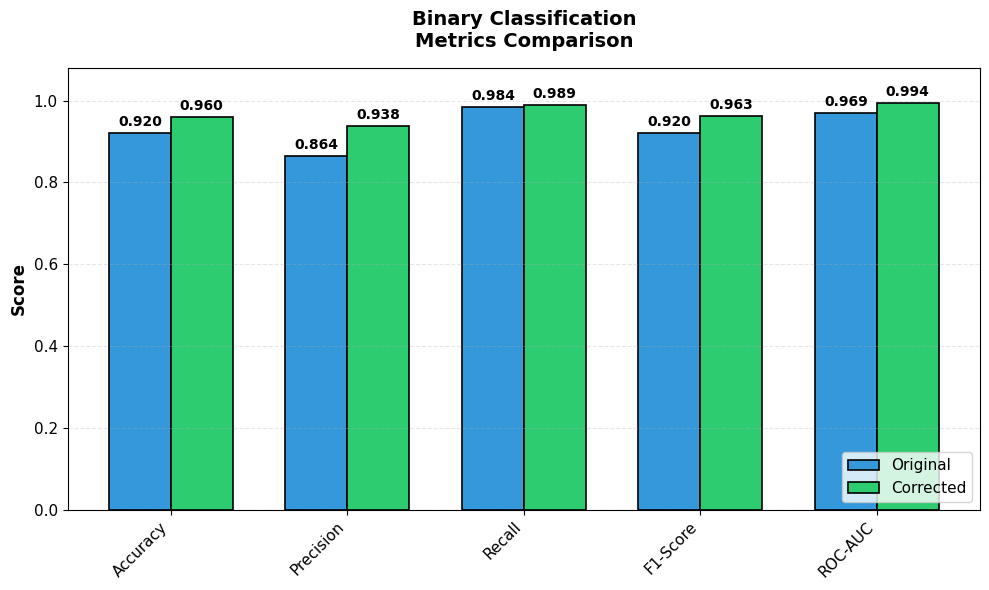

In [38]:
# 2. Binary Classification - Metrics Comparison
plt.figure(figsize=(10, 6))
x = np.arange(len(metrics_comparison_bin))
width = 0.35

bars1 = plt.bar(x - width/2, metrics_comparison_bin['Original'], width, 
                label='Original', color=color_original, edgecolor='black', linewidth=1.2)
bars2 = plt.bar(x + width/2, metrics_comparison_bin['Corrected'], width, 
                label='Corrected', color=color_corrected, edgecolor='black', linewidth=1.2)

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Binary Classification\nMetrics Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x, metrics_comparison_bin['Metric'], rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11, loc='lower right')
plt.ylim(0, 1.08)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('random_forest_results/binary_classification_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

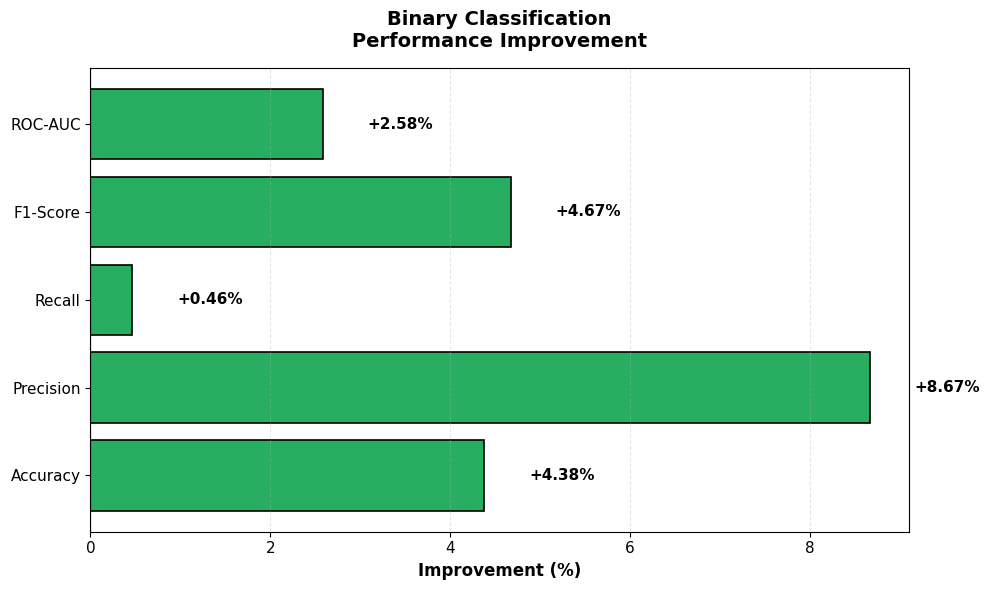

In [39]:
# 3. Binary Classification - Improvement
plt.figure(figsize=(10, 6))
colors = [color_improvement_pos if x > 0 else color_improvement_neg 
          for x in metrics_comparison_bin['Improvement %']]
bars = plt.barh(metrics_comparison_bin['Metric'], metrics_comparison_bin['Improvement %'], 
                color=colors, edgecolor='black', linewidth=1.2)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, metrics_comparison_bin['Improvement %'])):
    width = bar.get_width()
    label_x = width + (0.5 if width > 0 else -0.5)
    plt.text(label_x, bar.get_y() + bar.get_height()/2., f'{val:+.2f}%',
            ha='left' if width > 0 else 'right', va='center', 
            fontsize=11, fontweight='bold')

plt.xlabel('Improvement (%)', fontsize=12, fontweight='bold')
plt.title('Binary Classification\nPerformance Improvement', fontsize=14, fontweight='bold', pad=15)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
plt.yticks(fontsize=11)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig('random_forest_results/binary_classification_performance_improvement.png', dpi=300, bbox_inches='tight')
plt.show()

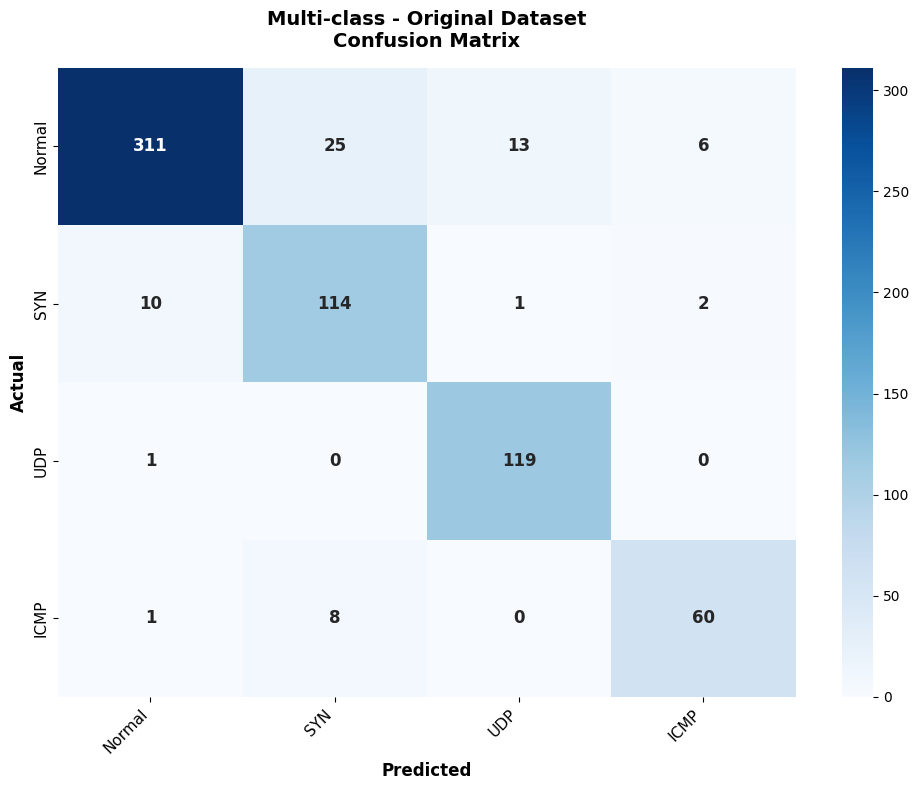

In [40]:
# 4. Multi-class - Original Dataset Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(results_orig_multi['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=results_orig_multi['class_names'],
            yticklabels=results_orig_multi['class_names'],
            cbar=True, annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Multi-class - Original Dataset\nConfusion Matrix', 
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.xticks(fontsize=11, rotation=45, ha='right')
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('random_forest_results/multi_class_original_dataset_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

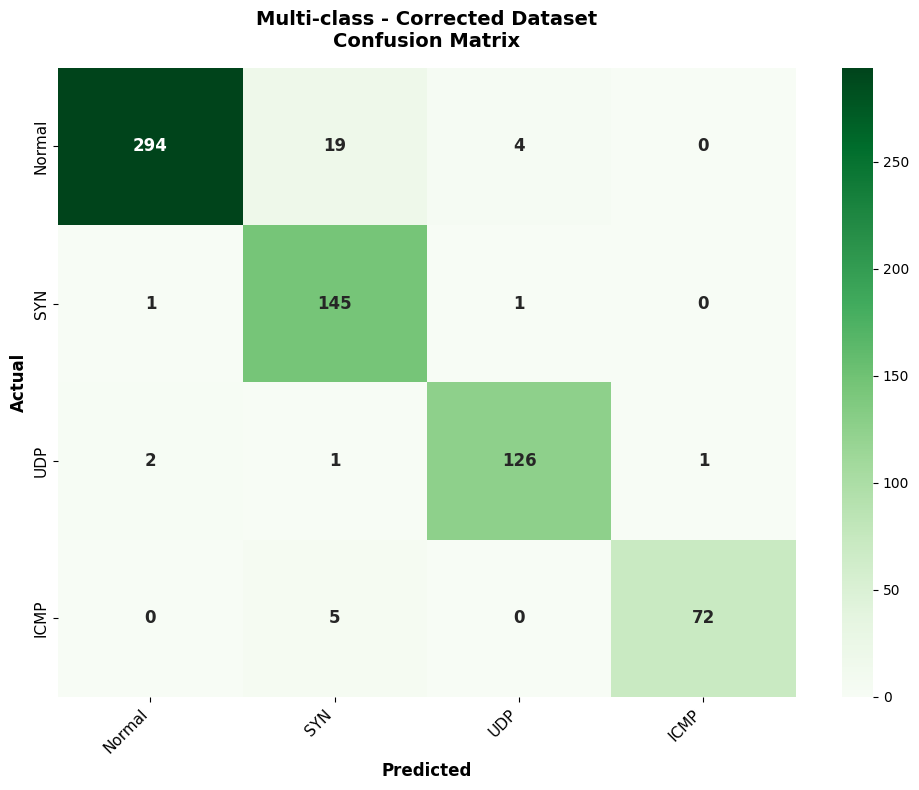

In [41]:
# 5. Multi-class - Corrected Dataset Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(results_corr_multi['confusion_matrix'], annot=True, fmt='d', cmap='Greens',
            xticklabels=results_corr_multi['class_names'],
            yticklabels=results_corr_multi['class_names'],
            cbar=True, annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Multi-class - Corrected Dataset\nConfusion Matrix', 
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.xticks(fontsize=11, rotation=45, ha='right')
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('random_forest_results/multi_class_corrected_dataset_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

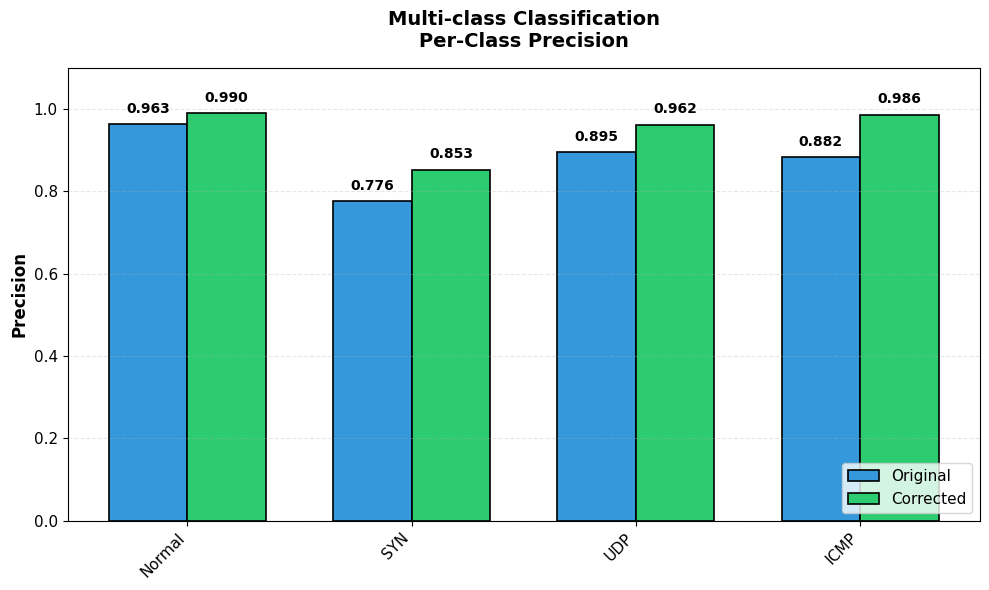

In [42]:
# 6. Per-class Precision Comparison (Multi-class)
plt.figure(figsize=(10, 6))
from sklearn.metrics import precision_score, recall_score

prec_orig = precision_score(y_test_orig_multi, results_orig_multi['y_pred'], average=None, zero_division=0)
prec_corr = precision_score(y_test_corr_multi, results_corr_multi['y_pred'], average=None, zero_division=0)

x_pos = np.arange(len(results_orig_multi['class_names']))
width = 0.35

bars1 = plt.bar(x_pos - width/2, prec_orig, width, label='Original', 
                color=color_original, edgecolor='black', linewidth=1.2)
bars2 = plt.bar(x_pos + width/2, prec_corr, width, label='Corrected', 
                color=color_corrected, edgecolor='black', linewidth=1.2)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Multi-class Classification\nPer-Class Precision', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x_pos, results_orig_multi['class_names'], rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11, loc='lower right')
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('random_forest_results/multi_class_classification_per_class_precision.png', dpi=300, bbox_inches='tight')
plt.show()

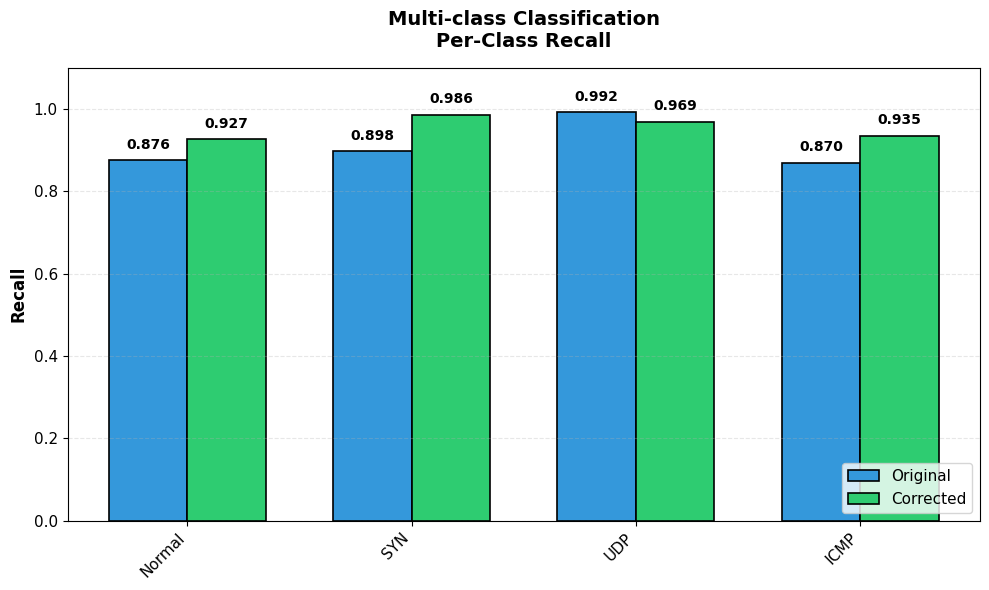

In [43]:
# 7. Per-class Recall Comparison (Multi-class)
plt.figure(figsize=(10, 6))
recall_orig = recall_score(y_test_orig_multi, results_orig_multi['y_pred'], average=None, zero_division=0)
recall_corr = recall_score(y_test_corr_multi, results_corr_multi['y_pred'], average=None, zero_division=0)

bars1 = plt.bar(x_pos - width/2, recall_orig, width, label='Original', 
                color=color_original, edgecolor='black', linewidth=1.2)
bars2 = plt.bar(x_pos + width/2, recall_corr, width, label='Corrected', 
                color=color_corrected, edgecolor='black', linewidth=1.2)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel('Recall', fontsize=12, fontweight='bold')
plt.title('Multi-class Classification\nPer-Class Recall', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x_pos, results_orig_multi['class_names'], rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11, loc='lower right')
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('random_forest_results/multi_class_classification_per_class_recall.png', dpi=300, bbox_inches='tight')
plt.show()

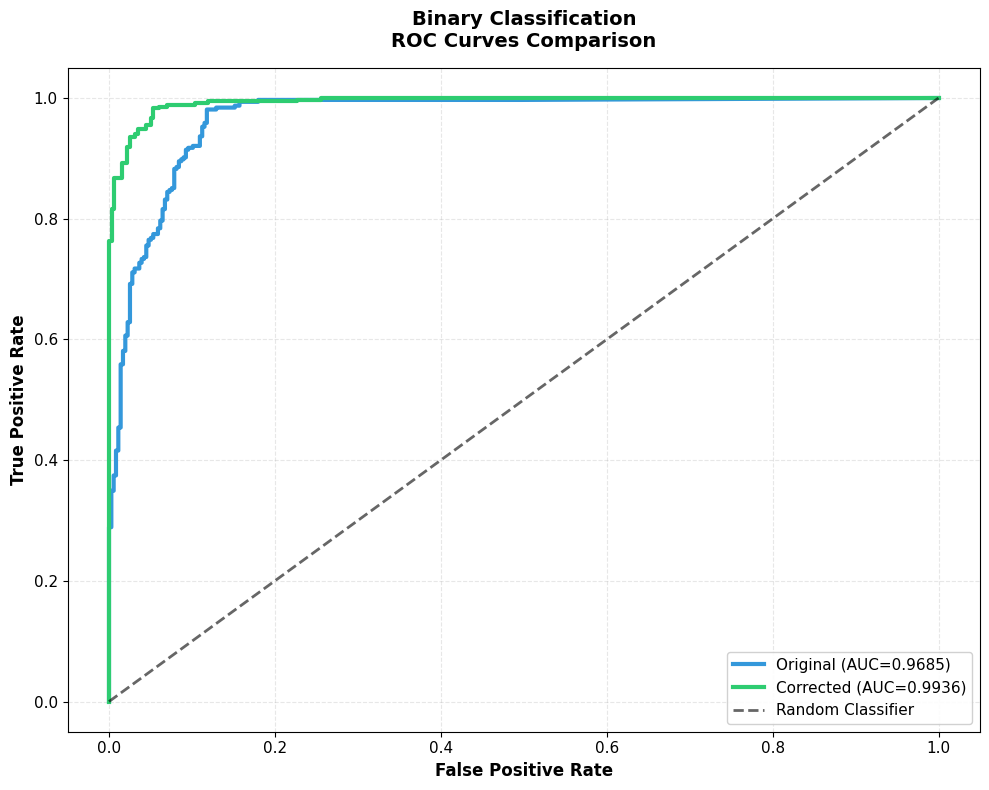

In [44]:
# 8. ROC Curves Comparison (Binary)
plt.figure(figsize=(10, 8))
from sklearn.metrics import roc_curve

fpr_orig, tpr_orig, _ = roc_curve(results_orig_bin['y_test'], results_orig_bin['y_pred_proba'])
fpr_corr, tpr_corr, _ = roc_curve(results_corr_bin['y_test'], results_corr_bin['y_pred_proba'])

plt.plot(fpr_orig, tpr_orig, linewidth=3, 
         label=f'Original (AUC={results_orig_bin["metrics"]["roc_auc"]:.4f})', 
         color=color_original, linestyle='-')
plt.plot(fpr_corr, tpr_corr, linewidth=3, 
         label=f'Corrected (AUC={results_corr_bin["metrics"]["roc_auc"]:.4f})', 
         color=color_corrected, linestyle='-')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier', alpha=0.6)

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Binary Classification\nROC Curves Comparison', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('random_forest_results/binary_classification_roc_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

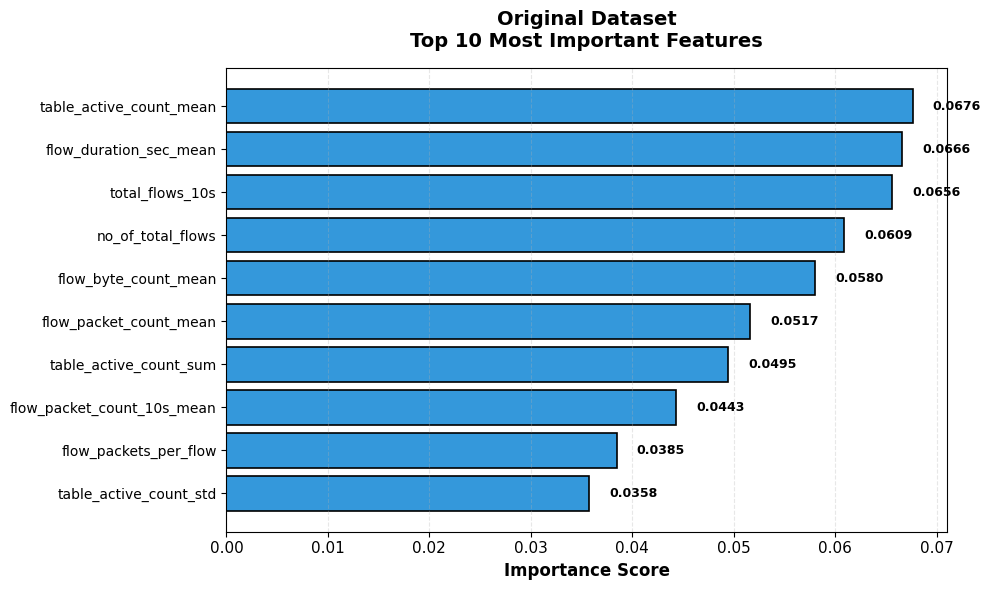

In [45]:
# 9. Feature Importance Top 10 - Original
plt.figure(figsize=(10, 6))
top_features_orig = results_orig_bin['feature_importance'].head(10)
bars = plt.barh(range(len(top_features_orig)), top_features_orig['importance'], 
                color=color_original, edgecolor='black', linewidth=1.2)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_features_orig['importance'])):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2., 
            f'{val:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')

plt.yticks(range(len(top_features_orig)), top_features_orig['feature'], fontsize=10)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('Original Dataset\nTop 10 Most Important Features', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig('random_forest_results/original_dataset_top10_most_important_features.png', dpi=300, bbox_inches='tight')
plt.show()

Checking feature importance data...
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (67, 2)
First few rows:
                   feature  importance
39       no_of_total_flows    0.079424
52         total_flows_10s    0.074491
6   flow_duration_sec_mean    0.067084
28  table_active_count_std    0.066365
4     flow_byte_count_mean    0.062498
Top 10 features shape: (10, 2)


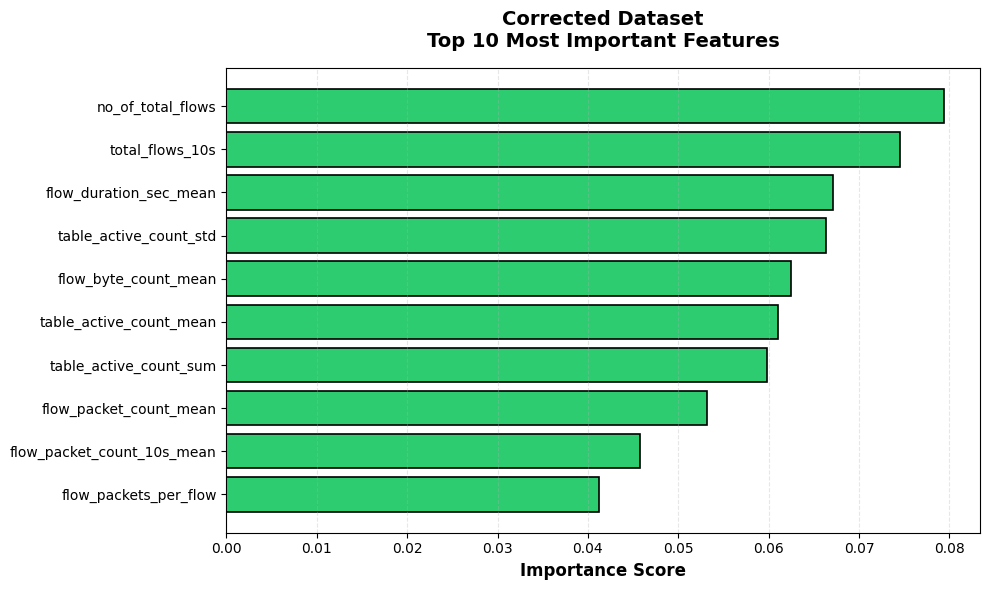

In [46]:
# 10. Feature Importance Top 10 - Corrected - DEBUG
print("Checking feature importance data...")
print(f"Type: {type(results_corr_bin['feature_importance'])}")
print(f"Shape: {results_corr_bin['feature_importance'].shape}")
print("First few rows:")
print(results_corr_bin['feature_importance'].head())

# Try with minimal plotting first
plt.figure(figsize=(10, 6))
top_features_corr = results_corr_bin['feature_importance'].head(10).copy()
print(f"Top 10 features shape: {top_features_corr.shape}")

# Simple plot without text labels first
plt.barh(range(len(top_features_corr)), top_features_corr['importance'], 
         color=color_corrected, edgecolor='black', linewidth=1.2)

plt.yticks(range(len(top_features_corr)), top_features_corr['feature'], fontsize=10)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('Corrected Dataset\nTop 10 Most Important Features', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
plt.tight_layout()
plt.savefig('random_forest_results/corrected_dataset_top10_important_features.png', dpi=300, bbox_inches='tight')
plt.show()

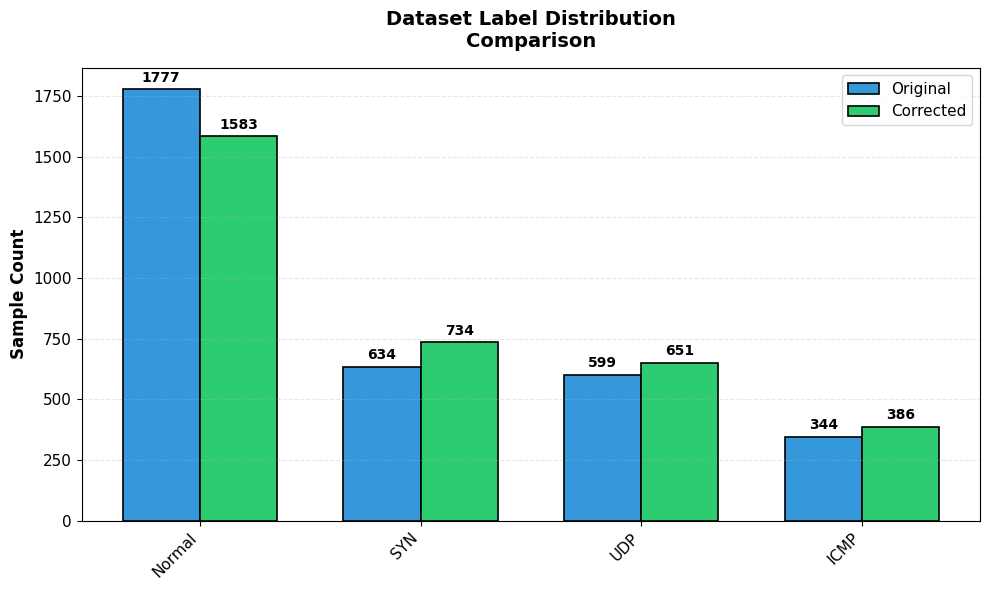

In [47]:
# 11. Dataset Label Distribution
plt.figure(figsize=(10, 6))
labels = ['Normal', 'SYN', 'UDP', 'ICMP']
orig_counts = [
    (df_original['attack'] == 0).sum(),
    df_original['attack_syn'].sum(),
    df_original['attack_udp'].sum(),
    df_original['attack_icmp'].sum()
]
corr_counts = [
    (df_corrected['attack'] == 0).sum(),
    df_corrected['attack_syn'].sum(),
    df_corrected['attack_udp'].sum(),
    df_corrected['attack_icmp'].sum()
]

x_pos = np.arange(len(labels))
width = 0.35

bars1 = plt.bar(x_pos - width/2, orig_counts, width, label='Original', 
                color=color_original, edgecolor='black', linewidth=1.2)
bars2 = plt.bar(x_pos + width/2, corr_counts, width, label='Corrected', 
                color=color_corrected, edgecolor='black', linewidth=1.2)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel('Sample Count', fontsize=12, fontweight='bold')
plt.title('Dataset Label Distribution\nComparison', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x_pos, labels, rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('random_forest_results/dataset_label_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

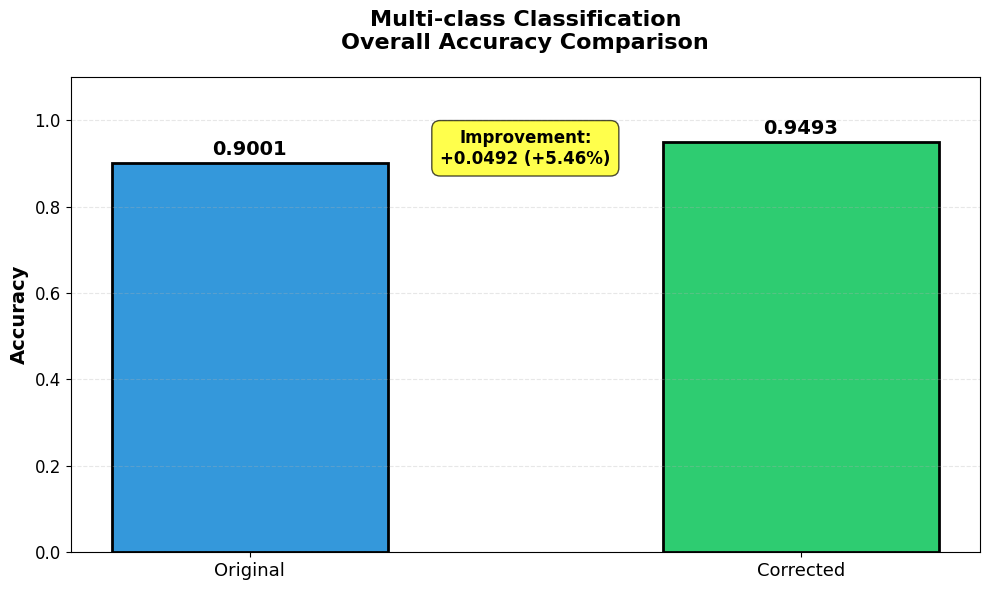

In [48]:
# Multi-class Accuracy Comparison
fig2, ax = plt.subplots(1, 1, figsize=(10, 6))

accuracy_comparison = pd.DataFrame({
    'Dataset': ['Original', 'Corrected'],
    'Accuracy': [results_orig_multi['accuracy'], results_corr_multi['accuracy']]
})

bars = plt.bar(accuracy_comparison['Dataset'], accuracy_comparison['Accuracy'],
               color=[color_original, color_corrected], 
               edgecolor='black', linewidth=2, width=0.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f}', ha='center', va='bottom', 
            fontsize=14, fontweight='bold')

# Add improvement annotation
improvement = results_corr_multi['accuracy'] - results_orig_multi['accuracy']
improvement_pct = (improvement / results_orig_multi['accuracy']) * 100

plt.annotate(f'Improvement:\n+{improvement:.4f} ({improvement_pct:+.2f}%)',
            xy=(0.5, max(accuracy_comparison['Accuracy']) - 0.05),
            ha='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
plt.title('Multi-class Classification\nOverall Accuracy Comparison', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.xticks(fontsize=13)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig('random_forest_results/multiclass_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
# Binary classification metrics
metrics_comparison_bin.to_csv('random_forest_results/binary_classification_comparison.csv', index=False)

# Multi-class per-class metrics
multiclass_metrics = pd.DataFrame({
    'Class': results_orig_multi['class_names'],
    'Precision_Original': prec_orig,
    'Precision_Corrected': prec_corr,
    'Recall_Original': recall_orig,
    'Recall_Corrected': recall_corr
})
multiclass_metrics['Precision_Improvement'] = multiclass_metrics['Precision_Corrected'] - multiclass_metrics['Precision_Original']
multiclass_metrics['Recall_Improvement'] = multiclass_metrics['Recall_Corrected'] - multiclass_metrics['Recall_Original']

multiclass_metrics.to_csv('random_forest_results/multiclass_classification_comparison.csv', index=False)

results_orig_bin['feature_importance'].to_csv('random_forest_results/feature_importance_random_forest_original.csv', index=False)
results_corr_bin['feature_importance'].to_csv('random_forest_results/feature_importance_random_fores_corrected.csv', index=False)